# 03 — Feature Engineering
Build RFM, behavioural, and cohort features. Validate before porting to `features/`.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
from pathlib import Path

sns.set_theme(style="whitegrid")
%matplotlib inline


## 2. Load cleaned data

In [2]:
df = pd.read_parquet("../data/interim/cleaned.parquet")
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
print(f"Shape: {df.shape}")
df.head()


Shape: (385081, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## 3. RFM features

In [3]:
snapshot_date = df["InvoiceDate"].max() + timedelta(days=1)
print(f"Snapshot date: {snapshot_date.date()}")

rfm = df.groupby("CustomerID").agg(
    Recency   = ("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency = ("InvoiceNo","nunique"),
    Monetary  = ("Revenue","sum"),
).reset_index()

rfm.describe()


Snapshot date: 2011-12-10


,Recency,Frequency,Monetary
count,4290.000000,4290.000000,4290.000000
mean,92.574592,4.191142,1607.563469
std,99.993918,7.465179,4815.340647
min,1.000000,1.000000,2.900000
25%,18.000000,1.000000,287.962500
50%,51.000000,2.000000,632.060000
75%,143.000000,5.000000,1540.470000
max,374.000000,205.000000,158967.800000


## 4. RFM distributions

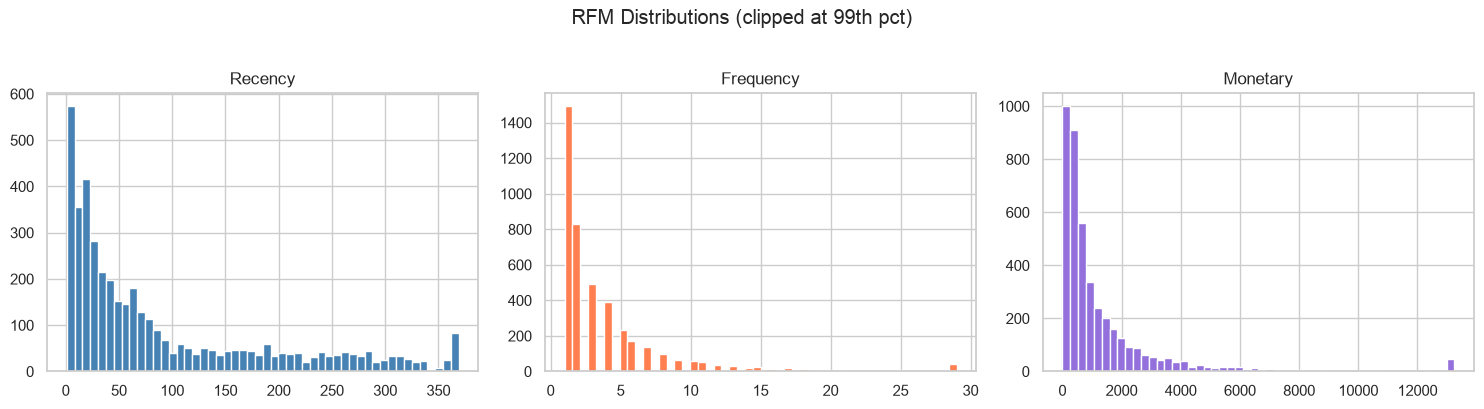

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, color in zip(axes, ["Recency","Frequency","Monetary"], ["steelblue","coral","mediumpurple"]):
    rfm[col].clip(upper=rfm[col].quantile(0.99)).hist(bins=50, ax=ax, color=color, edgecolor="white")
    ax.set_title(col)
plt.suptitle("RFM Distributions (clipped at 99th pct)", y=1.02)
plt.tight_layout()
plt.show()
